<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_3_Question_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def homogeneous(region, threshold=10):
    """Check if a region is homogeneous based on intensity variance."""
    return np.std(region) < threshold

In [2]:
def split(img, x, y, w, h, min_size, threshold):
    """Recursively split image into smaller homogeneous regions."""
    region = img[y:y+h, x:x+w]
    if w <= min_size or h <= min_size or homogeneous(region, threshold):
        return [(x, y, w, h)]
    else:
        w2, h2 = w // 2, h // 2
        regions = []
        regions += split(img, x, y, w2, h2, min_size, threshold)
        regions += split(img, x + w2, y, w2, h2, min_size, threshold)
        regions += split(img, x, y + h2, w2, h2, min_size, threshold)
        regions += split(img, x + w2, y + h2, w2, h2, min_size, threshold)
        return regions

In [4]:
def merge(img, regions, threshold):
    """Merge adjacent homogeneous regions (simplified version)."""
    output = np.zeros_like(img)
    for (x, y, w, h) in regions:
        mean_val = np.mean(img[y:y+h, x:x+w])
        output[y:y+h, x:x+w] = mean_val
    return output

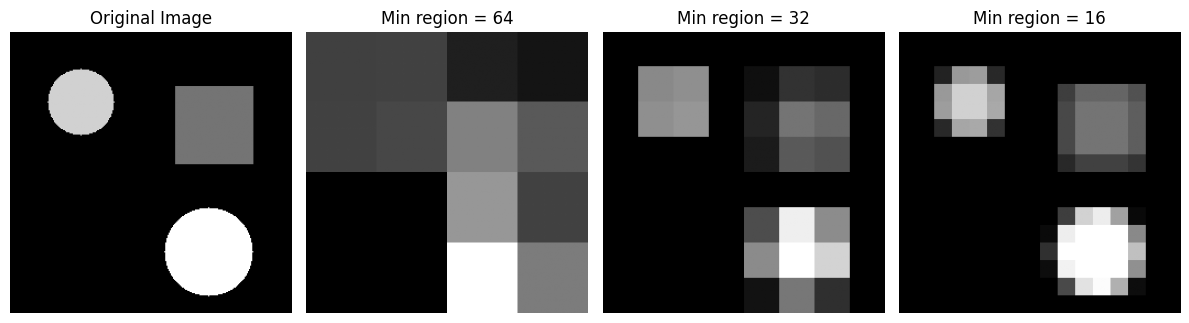

In [5]:
img = cv2.imread('blobs.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    # Create synthetic example if no image found
    img = np.zeros((256, 256), dtype=np.uint8)
    cv2.circle(img, (64, 64), 30, 180, -1)
    cv2.rectangle(img, (150, 50), (220, 120), 100, -1)
    cv2.circle(img, (180, 200), 40, 220, -1)

# Parameters
threshold = 15

# Try multiple minimum region sizes
sizes = [64, 32, 16]

plt.figure(figsize=(12, 4))
plt.subplot(1, len(sizes)+1, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

for i, min_size in enumerate(sizes):
    regions = split(img, 0, 0, img.shape[1], img.shape[0], min_size, threshold)
    merged_img = merge(img, regions, threshold)

    plt.subplot(1, len(sizes)+1, i+2)
    plt.imshow(merged_img, cmap='gray')
    plt.title(f"Min region = {min_size}")
    plt.axis("off")

plt.tight_layout()
plt.show()